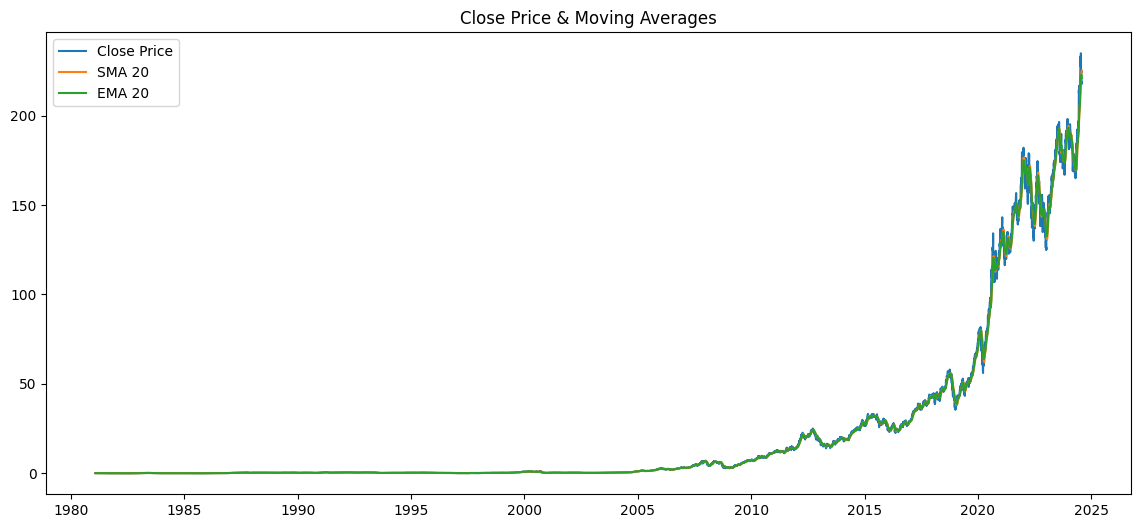

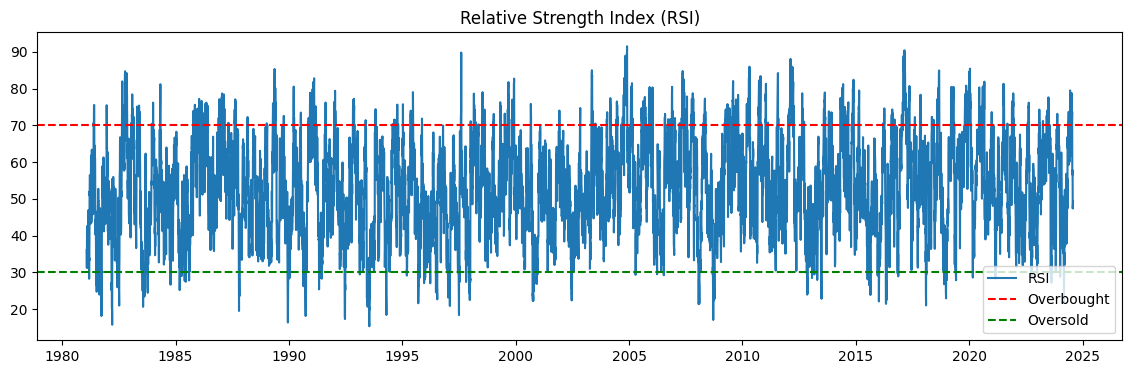

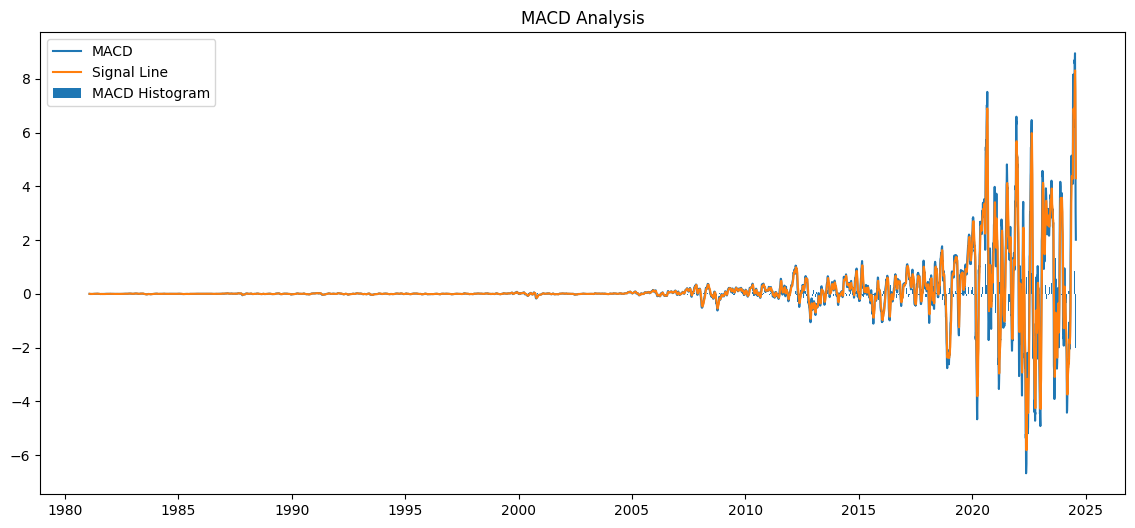

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ta 


# Load stock data
df = pd.read_csv("../yfinance_data/AAPL_historical_data.csv", parse_dates=['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

# Indicators using ta library
df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
macd = ta.trend.macd(df['Close'])
macd_signal = ta.trend.macd_signal(df['Close'])
macd_diff = ta.trend.macd_diff(df['Close'])
df['MACD'] = macd
df['MACD_signal'] = macd_signal
df['MACD_hist'] = macd_diff

# Drop NaNs
df.dropna(inplace=True)

# Plot Moving Averages
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20') 
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Close Price & Moving Averages")
plt.legend()
plt.show()

# Plot RSI
plt.figure(figsize=(14, 4))
plt.plot(df['RSI'], label='RSI')
plt.axhline(70, color='r', linestyle='--', label='Overbought')
plt.axhline(30, color='g', linestyle='--', label='Oversold')
plt.title("Relative Strength Index (RSI)")
plt.legend()
plt.show()

# Plot MACD
plt.figure(figsize=(14, 6))
plt.plot(df['MACD'], label='MACD')
plt.plot(df['MACD_signal'], label='Signal Line')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Analysis")
plt.legend()
plt.show()
